# Wing Coefficients Comparison — Baseline vs Optimised

LLT + NeuralFoil sweep for any number of configurations.

**Cells to edit before running:**
- **Cell 4** – wing geometry (pulled from `conf/test.yaml`) + number of LLT stations
- **Cell 6** – CST parameters (root & tip) for each configuration — edit values directly
- **Cell 8** – Re numbers, AoA range, device, model size
- **Cell 16** – inspection point for spanwise plots (AoA, Re)

Run all cells top-to-bottom.

In [2]:
from pathlib import Path
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt

ROOT = Path('/Users/gherardi/Documents/GitHub/glider_optimization')

from glider_optimization.config import load_config
from glider_optimization.utils.llt import build_llt_system
from glider_optimization.utils.cu_kulfan_airfoil import get_aero_from_kulfan_parameters_cuda

_cfg = load_config(ROOT / 'conf' / 'test.yaml')

## 1 — Wing geometry & station count

Wing planform is taken from `conf/test.yaml → plane.wing`.  
Edit **`N_STATIONS`** to control the number of LLT panels per half-wing.

In [3]:
# ── USER INPUT ───────────────────────────────────────────────────────────────
N_STATIONS = 30   # panels per half-wing (full wing = 2×N_STATIONS)
               # Use ≤ 12 with the half-cosine below; the centre panel width
               # must exceed rc_nf = 0.25*c_root ≈ 47 mm to avoid core saturation.

# wing planform from _cfg (loaded in cell above)
_wg = _cfg.plane['wing']

y_anchors   = np.array(_wg['y_half'],    dtype=float)
c_anchors   = np.array(_wg['c_half'],    dtype=float)
xle_anchors = np.array(_wg['xle_half'],  dtype=float)
tw_anchors  = np.array(_wg['twist_half'],dtype=float)
half_span   = float(y_anchors[-1])

# Standard half-cosine (Multhopp) distribution:
#   sparse at the root  →  wide centre panels (avoids rc_nf saturation)
#   dense  at the tip   →  resolves the tip vortex singularity
_t     = np.sin(np.linspace(0.0, np.pi / 2, N_STATIONS + 1))
y_half = y_anchors[0] + (half_span - y_anchors[0]) * _t
c_half   = np.interp(y_half, y_anchors, c_anchors)
xle_half = np.interp(y_half, y_anchors, xle_anchors)
tw_half  = np.interp(y_half, y_anchors, tw_anchors)

dy_min = float(np.diff(y_half).min())
rc_root = 0.25 * float(c_half[0])
print(f"Half-span: {half_span:.3f} m | Total panels: {N_STATIONS * 2}")
print(f"Centre panel half-width: {dy_min*1e3:.1f} mm   rc_nf(root): {rc_root*1e3:.1f} mm   "
      f"({'OK' if dy_min > rc_root else 'WARNING: dy < rc_nf — increase N_STATIONS or widen distribution'})")


Half-span: 0.420 m | Total panels: 60
Centre panel half-width: 0.6 mm   rc_nf(root): 46.9 mm   (WARNING: dy < rc_nf — increase N_STATIONS or widen distribution)


## 2 — CST parameters

Edit the values below directly. Each configuration requires a **root** and **tip** section:
- `upper_weights` / `lower_weights` – 8 floats each
- `leading_edge_weight` – float
- `TE_thickness` – float

The section shape is linearly interpolated root → tip along the span.  
Add/remove entries in `CONFIGS` to compare more configurations.

In [4]:
def _cst(d):
    """Normalise a raw CST dict to numpy arrays."""
    return {
        'upper_weights':       np.array(d['upper_weights'],  dtype=float),
        'lower_weights':       np.array(d['lower_weights'],  dtype=float),
        'leading_edge_weight': float(d['leading_edge_weight']),
        'TE_thickness':        float(d['TE_thickness']),
    }

# ── USER INPUT ───────────────────────────────────────────────────────────────
baseline_root = _cst({
    'upper_weights':       [0.18109497, 0.21268419, 0.28098503, 0.24864887, 0.2402814,  0.27262843, 0.25776474, 0.27817638],
    'lower_weights':       [-0.16965146, -0.09364138, -0.06345896, -0.0067966, -0.0902447, 0.02081845, -0.03575216, -0.00223623],
    'leading_edge_weight': 0.10647,
    'TE_thickness':        0.00257,
})
baseline_tip = _cst({
    'upper_weights':       [0.18109497, 0.21268419, 0.28098503, 0.24864887, 0.2402814,  0.27262843, 0.25776474, 0.27817638],
    'lower_weights':       [-0.16965146, -0.09364138, -0.06345896, -0.0067966, -0.0902447, 0.02081845, -0.03575216, -0.00223623],
    'leading_edge_weight': 0.10647,
    'TE_thickness':        0.00257,
})

optimised_root = _cst({
    'upper_weights':       [0.26972067, 0.25637513, 0.33920836, 0.30763113, 0.2581209 , 0.2366727 , 0.29646733, 0.38758296],
    'lower_weights':       [-0.10292772, -0.07350431,  0.02718162,  0.12175067,  0.05611458,  0.18334413,  0.14141344,  0.18649977],
    'leading_edge_weight': 0.20136789977550507,
    'TE_thickness':        0.0009318077354691923,
})
optimised_tip = _cst({
    'upper_weights':       [0.23467018, 0.23700565, 0.30681992, 0.27524328, 0.21206747, 0.22533017, 0.2832791 , 0.3739008 ],
    'lower_weights':       [-0.09271943, -0.09020413, -0.01438306,  0.07190611,  0.03333239,  0.17533018,  0.14016163,  0.18416603],
    'leading_edge_weight': 0.15997536480426788,
    'TE_thickness':        0.0,
})
# ─────────────────────────────────────────────────────────────────────────────

CONFIGS = {
    'Baseline':  {'root': baseline_root, 'tip': baseline_tip},
    'Optimised': {'root': optimised_root, 'tip': optimised_tip},
}
STYLES = {
    'Baseline':  {'color': 'tab:blue',   'ls': '-'},
    'Optimised': {'color': 'tab:orange', 'ls': '--'},
}

print("Configurations:", list(CONFIGS.keys()))

Configurations: ['Baseline', 'Optimised']


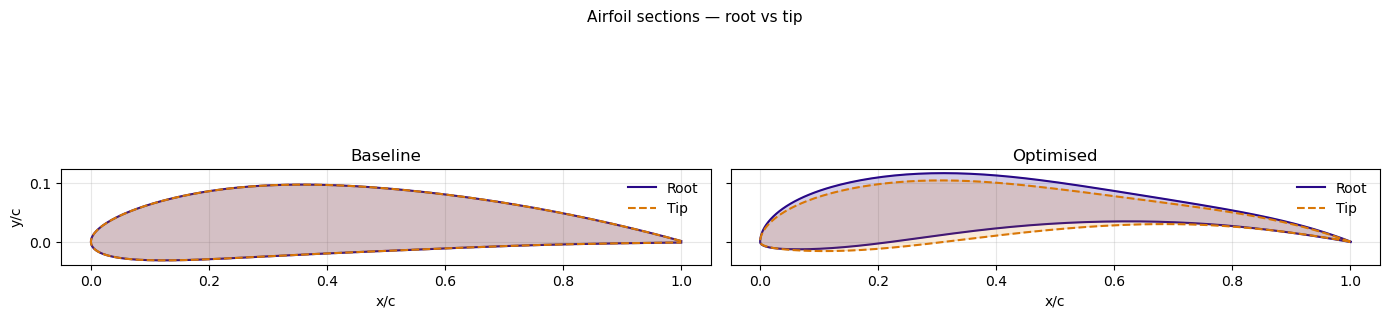

In [5]:
import aerosandbox as asb

def _kulfan_airfoil(cst, name=''):
    """Build an aerosandbox KulfanAirfoil from a CST dict."""
    return asb.KulfanAirfoil(
        name=name,
        upper_weights=cst['upper_weights'],
        lower_weights=cst['lower_weights'],
        leading_edge_weight=cst['leading_edge_weight'],
        TE_thickness=cst['TE_thickness'],
    )

_ROOT_COLOR = '#280887'
_TIP_COLOR  = '#d97706'

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True, sharey=True)

for ax, (name, cfg) in zip(axes, CONFIGS.items()):
    af_root = _kulfan_airfoil(cfg['root'], name=f'{name} Root')
    af_tip  = _kulfan_airfoil(cfg['tip'],  name=f'{name} Tip')

    x_r = np.reshape(np.array(af_root.x()), -1)
    y_r = np.reshape(np.array(af_root.y()), -1)
    x_t = np.reshape(np.array(af_tip.x()),  -1)
    y_t = np.reshape(np.array(af_tip.y()),  -1)

    ax.fill(x_r, y_r, color=_ROOT_COLOR, alpha=0.20, zorder=10)
    ax.plot(x_r, y_r,  color=_ROOT_COLOR, zorder=11, label='Root')

    ax.fill(x_t, y_t, color=_TIP_COLOR, alpha=0.15, zorder=12)
    ax.plot(x_t, y_t, '--', color=_TIP_COLOR,  zorder=13, label='Tip')

    ax.set_title(name)
    ax.set_aspect(1.0, adjustable='box')
    ax.legend(loc='upper right', frameon=False)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('x/c')

axes[0].set_ylabel('y/c')
plt.suptitle('Airfoil sections — root vs tip', fontsize=11)
plt.tight_layout()
plt.show()

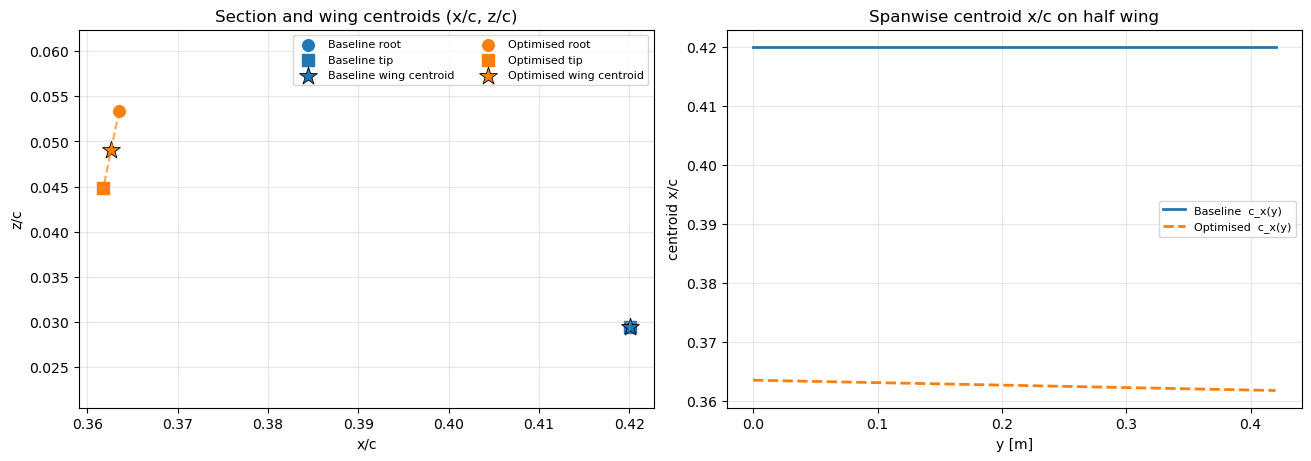

Baseline   | root=(+0.42003, +0.02951)  tip=(+0.42003, +0.02951)  wing=(+0.42003, +0.02951)
Optimised  | root=(+0.36353, +0.05338)  tip=(+0.36178, +0.04481)  wing=(+0.36266, +0.04909)


In [6]:
# Wing centroid visualisation for each configuration (Baseline / Optimised)

def _polygon_centroid(x, z):

    """Centroid of a closed polygon using the shoelace formula."""

    x = np.asarray(x, dtype=float).reshape(-1)

    z = np.asarray(z, dtype=float).reshape(-1)

    if x.size < 3:

        return np.nan, np.nan

    if not (np.isclose(x[0], x[-1]) and np.isclose(z[0], z[-1])):

        x = np.r_[x, x[0]]

        z = np.r_[z, z[0]]

    cross = x[:-1] * z[1:] - x[1:] * z[:-1]

    area2 = np.sum(cross)

    if np.isclose(area2, 0.0):

        return np.nan, np.nan

    cx = np.sum((x[:-1] + x[1:]) * cross) / (3.0 * area2)

    cz = np.sum((z[:-1] + z[1:]) * cross) / (3.0 * area2)

    return cx, cz



def _section_centroid_from_cst(cst):

    af = asb.KulfanAirfoil(

        name='tmp',

        upper_weights=cst['upper_weights'],

        lower_weights=cst['lower_weights'],

        leading_edge_weight=cst['leading_edge_weight'],

        TE_thickness=cst['TE_thickness'],

    )

    x = np.asarray(af.x(), dtype=float).reshape(-1)

    z = np.asarray(af.y(), dtype=float).reshape(-1)

    return _polygon_centroid(x, z)



def _wing_centroid(cfg_entry, y_half):

    """

    Compute spanwise-averaged centroid x/c based on linear interpolation

    of root/tip CST along stations defined by y_half.

    """

    y_half = np.asarray(y_half, dtype=float)

    half_span = float(y_half[-1])

    t = np.clip(y_half / max(half_span, 1e-12), 0.0, 1.0)



    cx_root, cz_root = _section_centroid_from_cst(cfg_entry['root'])

    cx_tip, cz_tip = _section_centroid_from_cst(cfg_entry['tip'])



    cx_span = (1.0 - t) * cx_root + t * cx_tip

    cz_span = (1.0 - t) * cz_root + t * cz_tip



    # Half-wing centroid via trapezoidal integration, mirrored full wing is identical.

    cx_wing = float(np.trapz(cx_span, y_half) / max(np.trapz(np.ones_like(y_half), y_half), 1e-12))

    cz_wing = float(np.trapz(cz_span, y_half) / max(np.trapz(np.ones_like(y_half), y_half), 1e-12))

    return {

        'cx_root': float(cx_root), 'cz_root': float(cz_root),

        'cx_tip': float(cx_tip), 'cz_tip': float(cz_tip),

        'cx_wing': cx_wing, 'cz_wing': cz_wing,

        'y_half': y_half, 'cx_span': cx_span, 'cz_span': cz_span,

    }



centroids = {name: _wing_centroid(cfg_entry, y_half) for name, cfg_entry in CONFIGS.items()}



fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)



# Left: section centroids at root/tip + span-averaged wing centroid

for name, c in centroids.items():

    st = STYLES.get(name, {'color': None, 'ls': '-'})

    color = st['color']

    axes[0].plot([c['cx_root'], c['cx_tip']], [c['cz_root'], c['cz_tip']],

                 ls=st['ls'], color=color, alpha=0.7)

    axes[0].scatter(c['cx_root'], c['cz_root'], marker='o', color=color, s=70, label=f'{name} root')

    axes[0].scatter(c['cx_tip'], c['cz_tip'], marker='s', color=color, s=70, label=f'{name} tip')

    axes[0].scatter(c['cx_wing'], c['cz_wing'], marker='*', color=color, s=180, edgecolor='k', linewidth=0.6,

                    label=f'{name} wing centroid')



axes[0].set_title('Section and wing centroids (x/c, z/c)')

axes[0].set_xlabel('x/c')

axes[0].set_ylabel('z/c')

axes[0].grid(True, alpha=0.3)

axes[0].axis('equal')

axes[0].legend(fontsize=8, ncol=2)



# Right: spanwise centroid trend

for name, c in centroids.items():

    st = STYLES.get(name, {'color': None, 'ls': '-'})

    axes[1].plot(c['y_half'], c['cx_span'], color=st['color'], ls=st['ls'], lw=2, label=f'{name}  c_x(y)')



axes[1].set_title('Spanwise centroid x/c on half wing')

axes[1].set_xlabel('y [m]')

axes[1].set_ylabel('centroid x/c')

axes[1].grid(True, alpha=0.3)

axes[1].legend(fontsize=8)



plt.show()



for name, c in centroids.items():

    print(

        f"{name:10s} | root=({c['cx_root']:+.5f}, {c['cz_root']:+.5f})  "

        f"tip=({c['cx_tip']:+.5f}, {c['cz_tip']:+.5f})  "

        f"wing=({c['cx_wing']:+.5f}, {c['cz_wing']:+.5f})"

    )


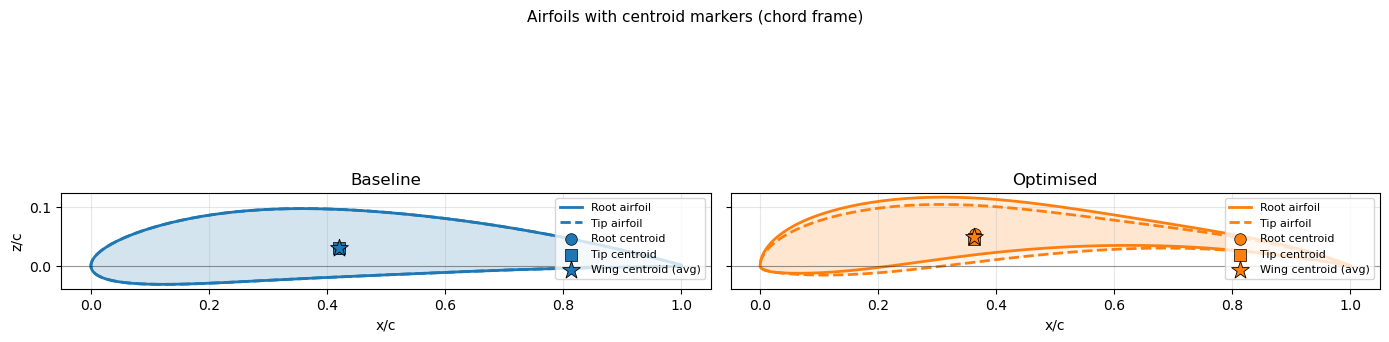

In [9]:
# Centroids overlaid on airfoils in the original chord frame

# Airfoils are NOT translated to centroid location; only centroid markers are plotted.



if 'centroids' not in globals():

    centroids = {name: _wing_centroid(cfg_entry, y_half) for name, cfg_entry in CONFIGS.items()}



fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharex=True, sharey=True)



for ax, (name, cfg_entry) in zip(axes, CONFIGS.items()):

    st = STYLES.get(name, {'color': None, 'ls': '-'})

    color = st['color']

    c = centroids[name]



    af_root = _kulfan_airfoil(cfg_entry['root'], name=f'{name} Root')

    af_tip = _kulfan_airfoil(cfg_entry['tip'], name=f'{name} Tip')



    x_r = np.asarray(af_root.x(), dtype=float).reshape(-1)

    z_r = np.asarray(af_root.y(), dtype=float).reshape(-1)

    x_t = np.asarray(af_tip.x(), dtype=float).reshape(-1)

    z_t = np.asarray(af_tip.y(), dtype=float).reshape(-1)



    ax.fill(x_r, z_r, color=color, alpha=0.12)

    ax.plot(x_r, z_r, color=color, lw=2.0, ls='-', label='Root airfoil')

    ax.fill(x_t, z_t, color=color, alpha=0.08)

    ax.plot(x_t, z_t, color=color, lw=2.0, ls='--', label='Tip airfoil')



    ax.scatter(c['cx_root'], c['cz_root'], marker='o', s=70, color=color, edgecolor='k', linewidth=0.5,

               label='Root centroid')

    ax.scatter(c['cx_tip'], c['cz_tip'], marker='s', s=70, color=color, edgecolor='k', linewidth=0.5,

               label='Tip centroid')

    ax.scatter(c['cx_wing'], c['cz_wing'], marker='*', s=180, color=color, edgecolor='k', linewidth=0.6,

               label='Wing centroid (avg)')



    ax.axhline(0.0, color='k', lw=0.8, alpha=0.35)

    ax.set_title(name)

    ax.set_xlabel('x/c')

    ax.grid(True, alpha=0.3)

    ax.legend(fontsize=8, loc='upper right')



axes[0].set_ylabel('z/c')

axes[0].set_aspect(1.0, adjustable='box')

axes[1].set_aspect(1.0, adjustable='box')

plt.suptitle('Airfoils with centroid markers (chord frame)', fontsize=11)

plt.tight_layout()

plt.show()

## 3 — Flow conditions

In [ ]:
# ── USER INPUT ───────────────────────────────────────────────────────────────
RE_NUMBERS             = np.arange(7500, 75_000 + 1, 33750)  # reference Re — one curve per Re on polars
AOA_MIN, AOA_MAX       = -15.0, 15.0         # degrees
AOA_STEP               = 1.0

DEVICE     = 'cpu'       # 'cpu' | 'cuda' | 'mps'
MODEL_SIZE = 'xxxlarge'  # neuralfoil model size

LLT_N_ITER = 30
LLT_BETA   = 0.40
LLT_TOL    = 1e-5
# ─────────────────────────────────────────────────────────────────────────────

_fp = _cfg.plane['flow']
RHO = float(_fp['rho'])
MU  = float(_fp['mu'])

AIRFLOW   = {'rho': RHO, 'mu': MU}
AOA_RANGE = np.arange(AOA_MIN, AOA_MAX + AOA_STEP / 2, AOA_STEP)
print(f"AoA: {AOA_RANGE[0]:.1f}° → {AOA_RANGE[-1]:.1f}°  ({len(AOA_RANGE)} pts)  |  Re: {RE_NUMBERS}")

AoA: -15.0° → 15.0°  (31 pts)  |  Re: [ 7500 41250 75000]


: 

: 

## 4 — LLT solver

In [10]:
def _run_llt(cst_root, cst_tip,
             y_half, c_half, xle_half, tw_half,
             aoa_range, re_numbers, airflow,
             n_iter, beta, tol, device, model_size):
    """
    Run LLT + NeuralFoil Picard iteration for every (AoA, Re) pair.

    For each reference Reynolds number Re_ref the velocity is derived as
        V = Re_ref * mu / (rho * cbar)
    and local panel Re is scaled by chord: Re_pan = Re_ref * c_mid / cbar.

    Returns
    -------
    df : pd.DataFrame
        Columns: AoA, Re, CL, CD, CM
    span_cache : dict[tuple, dict]
        Spanwise arrays keyed by (AoA, Re).
    """
    rho, mu = airflow['rho'], airflow['mu']

    # ── Build influence matrices from glider_optimization.utils.llt
    comp      = build_llt_system(y_half, c_half, xle_half, tw_half)
    D_nf      = comp['D_nf']
    D_tr      = comp['D_tr']
    mirror_of = comp['mirror_of']
    S         = comp['S']
    cbar      = comp['cbar']
    x_c4      = comp['x_c4_mid']
    x_ref     = comp['x_ref']
    c_mid     = comp['c_mid']
    y_mid     = comp['y_mid']
    tw_mid    = comp['tw_mid']
    dy        = comp['dy']

    # ── Pre-compute spanwise-interpolated Kulfan weights (numpy)
    # y_mid covers the full span (negative = left, positive = right); use |y| so
    # both sides mirror the same root→tip interpolation.
    t_norm = np.clip(np.abs(y_mid) / y_half[-1], 0.0, 1.0)
    uw_pan = np.stack([(1-t)*cst_root['upper_weights'] + t*cst_tip['upper_weights'] for t in t_norm])
    lw_pan = np.stack([(1-t)*cst_root['lower_weights'] + t*cst_tip['lower_weights'] for t in t_norm])
    le_pan = np.array([(1-t)*cst_root['leading_edge_weight'] + t*cst_tip['leading_edge_weight'] for t in t_norm])
    te_pan = np.array([(1-t)*cst_root['TE_thickness']        + t*cst_tip['TE_thickness']        for t in t_norm])

    def _nf(alpha_pan, Re_pan):
        kulfan = {
            'upper_weights_cuda':       torch.as_tensor(uw_pan, dtype=torch.float32),
            'lower_weights_cuda':       torch.as_tensor(lw_pan, dtype=torch.float32),
            'leading_edge_weight_cuda': torch.as_tensor(le_pan, dtype=torch.float32),
            'TE_thickness_cuda':        torch.as_tensor(te_pan, dtype=torch.float32),
        }
        with torch.no_grad():
            out = get_aero_from_kulfan_parameters_cuda(
                kulfan,
                torch.as_tensor(alpha_pan, dtype=torch.float32),
                torch.as_tensor(Re_pan,    dtype=torch.float32),
                model_size=model_size, device=device,
            )
        return {k: v.cpu().numpy() if isinstance(v, torch.Tensor) else np.asarray(v)
                for k, v in out.items()}

    rows       = []
    span_cache = {}
    n_no_conv  = 0   # count non-converged cases for reporting

    for Re_ref in re_numbers:
        # Velocity implied by the reference Re (using MAC as reference chord)
        V      = Re_ref * mu / (rho * cbar)
        # Local panel Re scaled by chord
        Re_pan = Re_ref * c_mid / cbar
        q_inf  = 0.5 * rho * V**2

        for aoa in aoa_range:
            alpha_geo = aoa + tw_mid
            Gamma     = 0.5 * V * c_mid * _nf(alpha_geo, Re_pan)['CL']

            converged = False
            for _ in range(n_iter):
                w_nf      = D_nf @ Gamma
                alpha_eff = alpha_geo - np.degrees(np.arctan2(w_nf, V))
                G_star    = 0.5 * V * c_mid * _nf(alpha_eff, Re_pan)['CL']
                G_new     = (1 - beta) * Gamma + beta * G_star
                G_new     = 0.5 * (G_new + G_new[mirror_of])
                rel_diff  = np.max(np.abs(G_new - Gamma)) / max(1.0, float(np.max(np.abs(Gamma))))
                Gamma     = G_new
                if rel_diff < tol:
                    converged = True
                    break

            if not converged:
                n_no_conv += 1

            w_nf      = D_nf @ Gamma
            w_tr      = D_tr @ Gamma
            alpha_eff = alpha_geo - np.degrees(np.arctan2(w_nf, V))
            aer       = _nf(alpha_eff, Re_pan)
            cl, cd, cm = aer['CL'], aer['CD'], aer['CM']

            Lp      = q_inf * c_mid * cl
            Di_pan  = rho * Gamma * w_tr
            L       = rho * V * np.sum(Gamma * dy)
            CD_val  = (np.sum(q_inf * c_mid * cd * dy) + np.sum(Di_pan * dy)) / (q_inf * S)
            CL_val  = L / (q_inf * S)
            M_pitch = np.sum((q_inf * c_mid**2 * cm - (x_c4 - x_ref) * Lp) * dy)
            CM_val  = M_pitch / (q_inf * S * cbar)

            rows.append({'AoA': aoa, 'Re': Re_ref, 'CL': CL_val, 'CD': CD_val, 'CM': CM_val})
            span_cache[(aoa, Re_ref)] = {
                'y_mid': y_mid, 'cl': cl, 'cd': cd,
                'w_tr': w_tr,   'Gamma': Gamma,
            }

    if n_no_conv:
        print(f"  ⚠  {n_no_conv}/{len(re_numbers)*len(aoa_range)} cases did NOT converge "
              f"in {n_iter} iterations — increase LLT_N_ITER or LLT_BETA")
    return pd.DataFrame(rows), span_cache


print("Solver ready.")


Solver ready.


## 5 — Run sweeps for all configurations

In [ ]:
RESULTS     = {}   # config_name -> DataFrame
SPAN_CACHES = {}   # config_name -> span_cache dict

for _name, _cfg_entry in CONFIGS.items():
    print(f"Running {_name}…", end=' ', flush=True)
    _df, _sc = _run_llt(
        cst_root=_cfg_entry['root'], cst_tip=_cfg_entry['tip'],
        y_half=y_half, c_half=c_half, xle_half=xle_half, tw_half=tw_half,
        aoa_range=AOA_RANGE, re_numbers=RE_NUMBERS,
        airflow=AIRFLOW,
        n_iter=LLT_N_ITER, beta=LLT_BETA, tol=LLT_TOL,
        device=DEVICE, model_size=MODEL_SIZE,
    )
    RESULTS[_name]     = _df
    SPAN_CACHES[_name] = _sc
    print("done")

print("\nAll runs complete.")

Running Baseline…   ⚠  5/93 cases did NOT converge in 30 iterations — increase LLT_N_ITER or LLT_BETA
done
Running Optimised…   ⚠  6/93 cases did NOT converge in 30 iterations — increase LLT_N_ITER or LLT_BETA
done

All runs complete.


: 

: 

## 6 — Polar plots: CL, CD, CM vs AoA

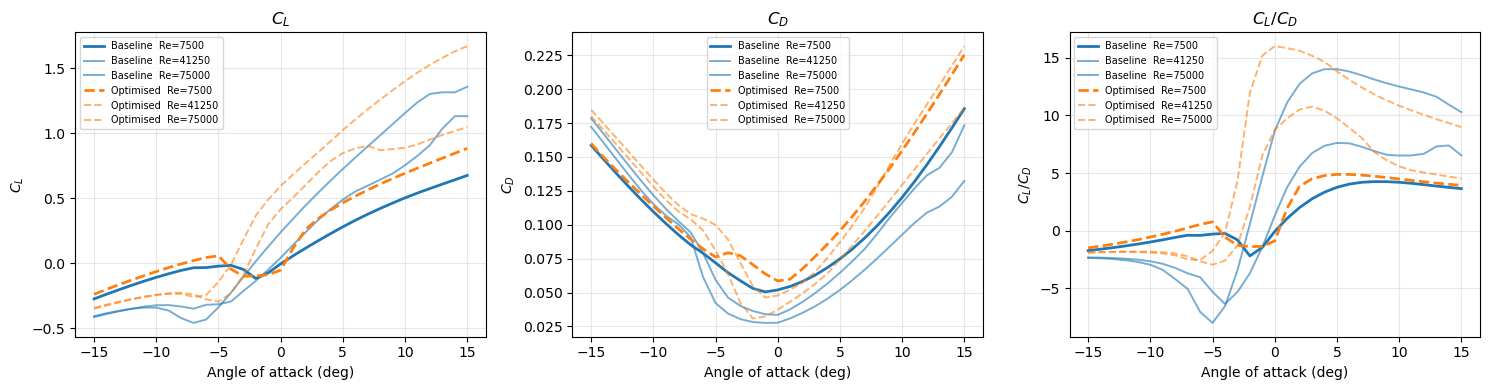

: 

: 

In [ ]:
_coeff_info = [
    ('CL',   r'$C_L$'),
    ('CD',   r'$C_D$'),
    ('CLCD', r'$C_L / C_D$'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (coeff, ylabel) in zip(axes, _coeff_info):
    for name, df in RESULTS.items():
        st = STYLES.get(name, {'color': None, 'ls': '-'})
        for i, Re in enumerate(RE_NUMBERS):
            sub = df[df['Re'] == Re].sort_values('AoA').copy()
            sub['CLCD'] = sub['CL'] / sub['CD']
            ax.plot(sub['AoA'], sub[coeff],
                    color=st['color'], ls=st['ls'],
                    linewidth=2.0 if i == 0 else 1.4,
                    alpha=1.0 if i == 0 else 0.6,
                    label=f"{name}  Re={Re:.0f}")
    ax.set_xlabel('Angle of attack (deg)')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

## 7 — Spanwise distributions

Set `INSPECT_AOA` and `INSPECT_V` to the condition you want to inspect.  
If those values were already computed in the sweep above the cached result is used directly — no re-run needed.

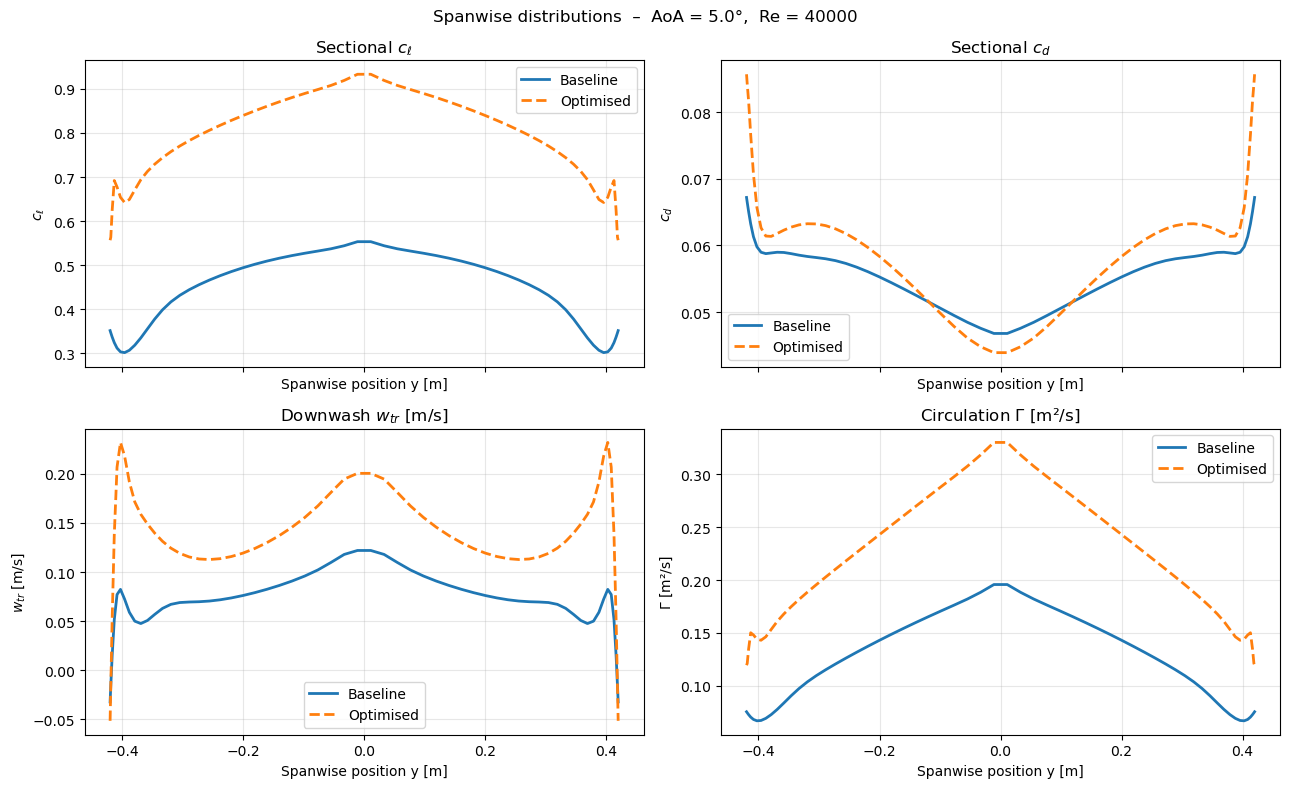

: 

: 

In [ ]:
# ── USER INPUT ───────────────────────────────────────────────────────────────
INSPECT_AOA = 5.0        # degrees
INSPECT_RE  = 40000    # reference Re
# ─────────────────────────────────────────────────────────────────────────────

def _get_span(name, aoa, Re):
    """Return spanwise dict, using cache when available."""
    key = (aoa, Re)
    if name in SPAN_CACHES and key in SPAN_CACHES[name]:
        return SPAN_CACHES[name][key]
    # Key not in cache (different value from sweep) — run a single-point solve
    cfg_entry = CONFIGS[name]
    _, sc = _run_llt(
        cst_root=cfg_entry['root'], cst_tip=cfg_entry['tip'],
        y_half=y_half, c_half=c_half, xle_half=xle_half, tw_half=tw_half,
        aoa_range=[aoa], re_numbers=[Re],
        airflow=AIRFLOW,
        n_iter=LLT_N_ITER, beta=LLT_BETA, tol=LLT_TOL,
        device=DEVICE, model_size=MODEL_SIZE,
    )
    return sc[(aoa, Re)]

_span_plots = [
    ('cl',    r'Sectional $c_\ell$',         r'$c_\ell$'),
    ('cd',    r'Sectional $c_d$',             r'$c_d$'),
    ('w_tr',  r'Downwash $w_{tr}$ [m/s]',     r'$w_{tr}$ [m/s]'),
    ('Gamma', r'Circulation $\Gamma$ [m²/s]', r'$\Gamma$ [m²/s]'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for ax, (key, title, ylabel) in zip(axes.ravel(), _span_plots):
    for name in CONFIGS:
        sp = _get_span(name, INSPECT_AOA, INSPECT_RE)
        st = STYLES.get(name, {'color': None, 'ls': '-'})
        ax.plot(sp['y_mid'], sp[key],
                color=st['color'], ls=st['ls'],
                linewidth=2, label=name)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Spanwise position y [m]')
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle(f'Spanwise distributions  –  AoA = {INSPECT_AOA}°,  Re = {INSPECT_RE:.0f}', fontsize=12)
plt.tight_layout()
plt.show()